# Module 1 - Introduction to Computer Vision  

This notebook launches the *Computer Vision Specialization*, introducing the fundamental concepts of Computer Vision, the OpenCV library, and image manipulation techniques. Throughout this module, we will explore the basics of image processing using the OpenCV library. We'll start by importing the necessary libraries, including OpenCV (`cv2`).  

Before running this *notebook*, make sure you have followed the initial recommendations and executed the [Initial Jupyter Notebook](./00_Config.ipynb).  

This notebook is part of the [Computer Vision Specialization](https://escola.sigmoidal.ai/especializacao-em-visao-computacional) program. It has been adapted and improved by Carmen Scartezini. You can check the original code [here](https://github.com/carlosfab/visao-computacional).

## 1.1 - Getting to Know the OpenCV Library  

OpenCV is a C++ programming library with real-time capabilities. As it is written in optimized C/C++, the library can benefit from multi-core processing. A theoretical introduction to the OpenCV library is presented in the next section.  

The OpenCV library is popular for several reasons, including:  

- It's an open-source computer vision library  
- It's specifically designed for image processing  
- Contains over 2,500 optimized algorithms, including state-of-the-art computer vision algorithms  
- Supports machine learning and deep learning  
- Provides interfaces for C++, Python, Java, and MATLAB  
- Supports Windows, Linux, Android, and macOS  

### 1.1.1 - OpenCV Modules  

OpenCV is divided into several modules. Each module can generally be understood as being dedicated to a group of computer vision problems. The main modules are briefly described here.  

<center>
    <img src="img/modulos-opencv.png">
</center>  

- `core`: *Core functionality*. Defines basic data structures and fundamental functions used by all other modules.  
- `imgproc`: *Image processing*. Includes image filtering, geometric transformations, color space conversion, and histograms.  
- `imgcodecs`: *Image codecs*. Reading and writing image files.  
- `videoio`: *Video I/O*. Interface for video capture and video codecs.  
- `highgui`: *High-level GUI*. Provides functionality to:  
    - Create and manipulate windows that can display images  
    - Add trackbars to windows, keyboard commands, and handle mouse events  
- `video`: *Video analysis*. Includes background subtraction, motion estimation, and object tracking algorithms.  
- `calib3d`: *Camera calibration and 3D reconstruction*. Covers multi-view geometry, stereo correspondence, pose estimation, and 3D reconstruction.  
- `features2d`: *2D features framework*. Includes feature detectors, descriptors, and matchers.  
- `objdetect`: *Object detection*. Detection of objects and instances of predefined classes (e.g., faces, eyes, people, cars).  
- `dnn`: *Deep Neural Network module*. Contains:  
    - API for creating new layers  
    - Set of useful built-in layers  
    - API for building and modifying neural networks  
    - Functionality to load serialized models from different deep learning frameworks  
- `ml`: *Machine Learning*. Contains classes and methods for classification, regression, and clustering.  
- `flann`: *Clustering and search in multi-dimensional spaces*. Fast Library for Approximate Nearest Neighbors.  
- `photo`: *Computational photography*. Implements algorithms for photo processing.  
- `stitching`: *Image stitching*. Implements panorama stitching pipeline.  
- `shape`: *Shape distance and matching*. Used for shape matching, retrieval, and comparison.  
- `superres`: *Super resolution*. Contains methods for resolution enhancement.  
- `videostab`: *Video stabilization*. Contains methods for video stabilization.  
- `viz`: *3D Visualizer*. Used for displaying 3D widgets and scenes.  

## 1.2 - Handling Files and Images with OpenCV

First, we'll cover how to load images from disk using OpenCV's `imread` function, followed by a detailed explanation of its parameters and return values. We'll examine the structure of the loaded image in detail, focusing on pixel intensity and image properties such as pixel type and dimensions.

Next, we'll discuss various ways to display the loaded images. We'll explore why the `plt.imshow()` method from `matplotlib` is more suitable for the Jupyter notebook environment compared to OpenCV's `cv2.imshow()` function (which is more appropriate when running standalone *scripts*, for example). Additionally, we'll highlight some particularities about grayscale image representation.

Finally, we'll begin manipulating image pixels, which represents a crucial step in image processing. Throughout this notebook, we'll use practical examples to illustrate these concepts, providing comprehensive and hands-on understanding of how to work with images using OpenCV and Python.


In [6]:
# Importar os pacotes necessários
import cv2
import numpy as np
from typing import Optional
import matplotlib.pyplot as plt
from pathlib import Path
import sys

%matplotlib inline


### 1.2.1 - Loading Images with OpenCV

Let's begin by reading an image from disk using OpenCV's `imread` function. The syntax for this in Python and C++ is as follows:

The commands below load the specified image from disk into memory. In Python, the image is stored as a NumPy multidimensional array object, while in C++ it's stored as a `Mat` object.

#### <font style="color:rgb(0, 0, 128)">Function Syntax</font>

```python
cv2.imread(
    filename: str,
    flags: Optional[int] = None
) -> np.ndarray



In [7]:
path_img_c = Path.cwd().parent.parent / "data" / "c_cinza.png"
letter_c = cv2.imread(path_img_c, cv2.IMREAD_GRAYSCALE)
print(letter_c)

[[255 255 255 255 255 255 255 255 255 255 255 255 255   0   0]
 [255 255 255 255 255 255 255 255 255 255 255 255 255   0   0]
 [255 255 255 255 255 255 255 255 255 255 255 255 255   0   0]
 [255 255 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [255 255 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [255 255 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [255 255 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [255 255 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [255 255 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [255 255 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [255 255 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [255 255 255   0   0   0   0   0   0   0   0   0   0   0   0]
 [255 255 255 255 255 255 255 255 255 255 255 255 255   0   0]
 [255 255 255 255 255 255 255 255 255 255 255 255 255   0   0]
 [255 255 255 255 255 255 255 255 255 255 255 255 255   0   0]]


The values above refer to the intensity of each pixel. In this case, 0 represents the black points in the image and 255 represents the white ones.

In [8]:
type(letter_c)

numpy.ndarray

**Dimensional Properties of Images**

In OpenCV, image dimensions are represented as a tuple in the form $ \text{width} \times \text{height} $ or, equivalently, $ \text{\# of columns} \times \text{\# of rows} $. On the other hand, in NumPy, the `shape` method returns image dimensions as a tuple in reverse order, that is, $ \text{height} \times \text{width} $.

This highlights the need for careful attention when manipulating image dimensions, given the difference in conventions adopted by each library.

In [9]:
print("Type (pixels): {}\n".format(letter_c.dtype))
print("Type (object): {}\n".format(type(letter_c.dtype)))
print("Dimensions: {}\n".format(letter_c.shape))

Type (pixels): uint8

Type (object): <class 'numpy.dtypes.UInt8DType'>

Dimensions: (15, 15)



### 1.2.2 - Displaying Images

When working with image processing and visualization tasks, there are several options for displaying images. The choice of display method often depends on the working environment - whether it's a Jupyter notebook or a Python script running in an IDE.

OpenCV's `cv2.imshow()` function, while useful, may cause issues in a Jupyter notebook as it can crash the kernel and interrupt notebook execution.

Therefore, for a Jupyter notebook environment, it's more appropriate to use matplotlib's `plt.imshow()` method. This method reads and graphically displays a NumPy array, making it a convenient option for image visualization.

If you're using Google Colab, there's yet another option: you can use `from google.colab.patches import cv2_imshow` to display images with the `cv2_imshow()` function.

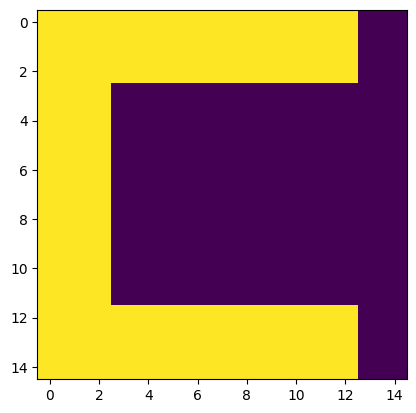

In [10]:
#Display the image using matplotlib
plt.imshow(letter_c);

**Important:** One of the key considerations when working with images is color scale handling. In our case, we loaded the image in grayscale, but it's crucial to understand that matplotlib - the library responsible for displaying images in our notebook - doesn't automatically assume it should use a grayscale colormap for image representation.

By default, matplotlib uses a color scale called `viridis`, which is a perceptually uniform color map. Therefore, even if we load a grayscale image, unless we explicitly specify `cmap='gray'`, the display won't be in grayscale.

To solve this issue, we need to instruct matplotlib to use a grayscale colormap when displaying our images. This can be done with the following command: `matplotlib.rc('image', cmap='gray')`.

This command should be included at the beginning of the notebook. By doing this, we're configuring matplotlib to use grayscale colormap by default when displaying images. This way, any subsequently loaded grayscale image will be displayed correctly, without needing to specify the colormap each time. This simplifies the visualization process and ensures images are displayed with proper color representation.

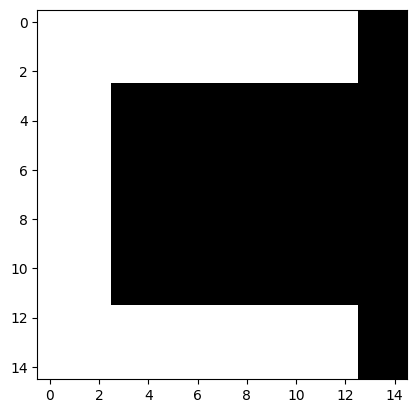

In [11]:
plt.imshow(letter_c, cmap='gray');

### 1.2.3 - Manipulating Pixels

Now that we’ve seen how to load and display an image, let’s move on to pixel manipulation. As mentioned earlier, an image is made up of a matrix of pixels, each with its own intensity value.

We will explore how to access, modify, and manipulate these pixels to make desired changes to the image. We'll also introduce the important concept of Region of Interest (ROI), which refers to a specific sub-region of the image that we want to process.

You can access a specific pixel in an image by simply indexing the image matrix. For example, `img[0, 0]` gives you the pixel in the top-left corner. If the image is in color, this will return an array with three values representing the red, green, and blue channels, respectively. In a grayscale image, it will return a single value representing the pixel’s intensity.

Similarly, you can modify a pixel by assigning a new value to its position in the image matrix.


In [12]:
# Accessing the pixel value located in the first row and third column
original_pixel_value = letter_c[0, 2]
print("Original pixel value at 1st row and 3rd column:", original_pixel_value)

# Modifying the pixel value in the first row and third column to 0
letter_c[0, 2] = 0

# Accessing and displaying the new modified pixel value
modified_pixel_value = letter_c[0, 2]
print("Pixel value at 1st row and 3rd column after modification:", modified_pixel_value)

Original pixel value at 1st row and 3rd column: 255
Pixel value at 1st row and 3rd column after modification: 0


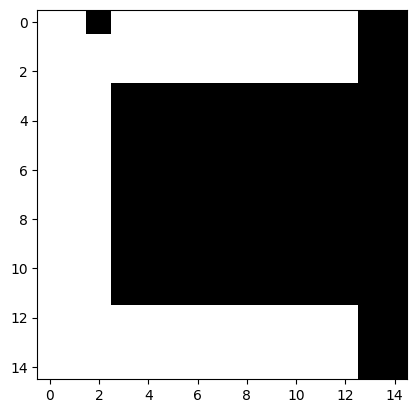

In [13]:
plt.imshow(letter_c, cmap='gray');

Em muitos casos, talvez queiramos trabalhar com uma sub-região da imagem, também conhecida como Região de Interesse (ROI). Podemos facilmente definir uma ROI em uma imagem utilizando a ` de matrizes, da mesma forma que faríamos com uma matriz numpy padrão.

In [14]:
roi = letter_c[0:10, 0:5]
print(roi)

[[255 255   0 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255   0   0]
 [255 255 255   0   0]
 [255 255 255   0   0]
 [255 255 255   0   0]
 [255 255 255   0   0]
 [255 255 255   0   0]
 [255 255 255   0   0]]


Text(0.5, 1.0, 'ROI')

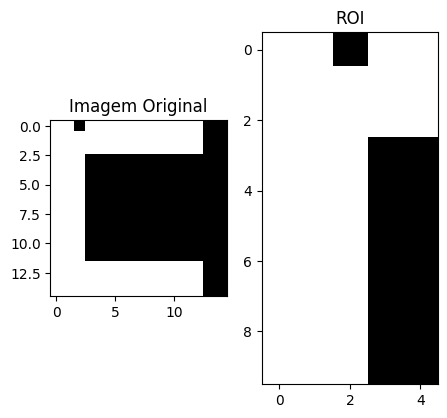

In [15]:
plt.figure(figsize=[5, 5])
plt.subplot(121)
plt.imshow(letter_c, cmap='gray')
plt.title('Imagem Original')
plt.subplot(122)
plt.imshow(roi, cmap='gray')
plt.title('ROI')

Quando exibimos uma ROI, talvez queiramos que ela seja exibida na mesma escala da imagem original. No entanto, o matplotlib não mantém automaticamente a escala original ao exibir a ROI. Para corrigir isso, podemos calcular a escala da ROI em relação à imagem original e usar essa escala para definir o tamanho da figura quando exibimos a ROI.

Text(0.5, 1.0, 'Region of Interest (ROI)')

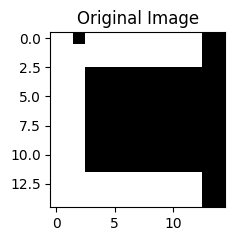

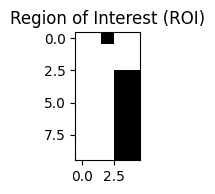

In [16]:
# Get dimensions of the original image and the ROI
h_original, w_original = letter_c.shape[:2]
h_roi, w_roi = roi.shape[:2]

# Set the figure size for the original image (in inches)
figsize_original = (5, 5)

# Compute scale factor of ROI relative to original image
scale = min(h_roi / h_original, w_roi / w_original)

# Adjust figure size for the ROI based on the original image scale
figsize_roi = (figsize_original[0] * scale, figsize_original[1] * scale)

# Display the original image
plt.figure(figsize=figsize_original)
plt.subplot(211)
plt.imshow(letter_c, cmap='gray')
plt.title('Original Image')

# Display the ROI in a separate figure with scaled size
plt.figure(figsize=figsize_roi)
plt.imshow(roi, cmap='gray')
plt.title('Region of Interest (ROI)')


### 1.2.4 - Saving Images with OpenCV

After manipulating an image using OpenCV, we often want to save the result to disk. This can be easily done using OpenCV's `imwrite` function. The syntax is similar in both Python and C++.

The commands below save the specified image from memory to disk. In Python, the image is represented as a multidimensional NumPy array, while in C++ it is a `Mat` object.

#### <font style="color:rgb(0, 0, 128)">Function Sintaxe</font>

``` python
cv2.imwrite(
    filename: str,
    img: np.ndarray,
    params: Optional[List[int]] = None
) -> bool
```

**Parameters**  
`filename` is the name of the file to which the image will be saved. This argument is **required**.  
`img` is the image to be saved. This argument is **required**.  
`params` is an optional sequence of pairs (property/value) to specify compression format. For JPEG images, for example, it can be: `[cv2.IMWRITE_JPEG_QUALITY, 90]` to specify JPEG quality (default is 95).

The `imwrite` function returns a boolean. If the file is successfully saved, the function returns `True`. If an error occurs during saving, the function returns `False`.

For a complete understanding of the `imwrite` function and its options, you can consult the [official OpenCV documentation](https://docs.opencv.org/4.7.0/d4/da8/group__imgcodecs.html#ga292d81be8d76901bff7988d18d2b42ac).


In [17]:
#Saving image
path_img_c_roi = Path.cwd().parent.parent / "data" / "c_cinza_roi.png"
cv2.imwrite(path_img_c_roi, roi)

True

Now let's load this newly processed image and see how the result was saved in the file `c_cinza_roi.png`.


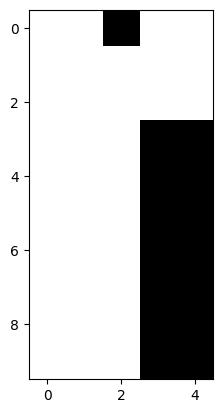

In [18]:
path_img_c_roi = Path.cwd().parent.parent / "data" / "c_cinza_roi.png"
img_manipulada = cv2.imread(path_img_c_roi, 0)
plt.imshow(img_manipulada, cmap='gray');

## 1.3 - Geometric Transformations

Resizing images is also necessary when working with Computer Vision. This can be done simply, as shown below. If you want to learn more about *interpolation*, here is a [reference link](https://www.cambridgeincolour.com/tutorials/image-interpolation.htm) on the topic.

### 1.3.1 - Scaling

The first manipulation we will perform in this regard is scaling. This is useful to increase or decrease the size of an image. The function `cv2.resize` is used to resize the image to the desired dimensions. In the case `resized_image = cv2.resize(image, (2000, 300), interpolation=cv2.INTER_LINEAR)`, the image is resized to a width of 2000 pixels and height of 300 pixels using linear interpolation.

- To enlarge the image:
    - Generally, the best approach is `cv2.INTER_CUBIC` or `cv2.INTER_LINEAR`
- To reduce the image:
    - Generally, the best approach is to use `cv2.INTER_LINEAR`


In [19]:
sigmoidal_path = str(Path.cwd().parent.parent / "sigmoidal")
if sigmoidal_path not in sys.path:
    sys.path.append(sigmoidal_path)

# 2. Importa TUDO com alias
import utils.notebook as sig

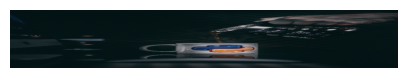

In [20]:
# carregar a imagem
image_cafe = Path.cwd().parent.parent / "data" / "cafe.png"
image = cv2.imread(image_cafe)

# redimensionar a imagem para 2000 x 300 pixels
resized_image = cv2.resize(image, (2000, 300), interpolation=cv2.INTER_LINEAR)

# plotar a imagem
sig.plot_image(resized_image)

### 1.3.2 - Scaling with ratio

Adjusting the `ratio` of an image is a geometric transformation that changes the image dimensions while maintaining its aspect ratio. The code `cv2.resize(image, None, fx=0.3, fy=0.3, interpolation=cv2.INTER_LINEAR)` uses OpenCV's `resize` function to scale the image by factors `fx` and `fy` to 30% of the original size, both in width and height.

The `interpolation` specified as `cv2.INTER_LINEAR` ensures smooth pixel transitions when resizing the image. The function `sig.plot_image(dst_image)` is then called to display the resized image.



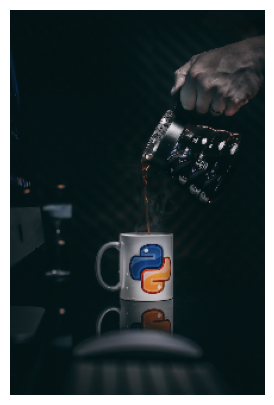

In [21]:
# Resize the image using a ratio of 0.3
dst_image = cv2.resize(image, None, fx=0.3, fy=0.3, interpolation=cv2.INTER_LINEAR)
sig.plot_image(dst_image)

### 1.3.3 - Translation

Translation is a type of geometric transformation that shifts an image in a specific direction within a two-dimensional space. Using OpenCV, we can apply translation through a transformation matrix that defines the amount of displacement along the x (horizontal) and y (vertical) axes.

For example, `M = np.float32([[1, 0, tx], [0, 1, ty]])` creates a translation matrix where `tx` and `ty` are the distances to shift along the x and y axes, respectively. This transformation is applied using the function `cv2.warpAffine(image, M, (width, height))`, which effectively moves the image to its new position. This process is essential in many computer vision tasks such as image alignment and panorama correction.


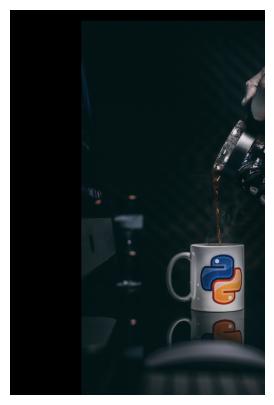

In [22]:
# Perform image translation
height, width = image.shape[:2]
M = np.float32([[1, 0, 200], [0, 1, 30]])
dst_image = cv2.warpAffine(image, M, (width, height))
sig.plot_image(dst_image)

### 1.3.4 - Rotation

Image rotation is a geometric transformation that changes the orientation of an image by rotating it around a central point. In the provided code snippet, `cv2.getRotationMatrix2D` is used to create a rotation matrix. This function takes as parameters the image center `(width / 2.0, height / 2.0)`, the rotation angle `180` degrees, and the scale factor `1`. Using this matrix, `cv2.warpAffine` applies the transformation to the original image, resulting in `dst_image`, which is the image rotated by 180 degrees. The resulting image is then displayed using `sig.plot_image(dst_image)`.



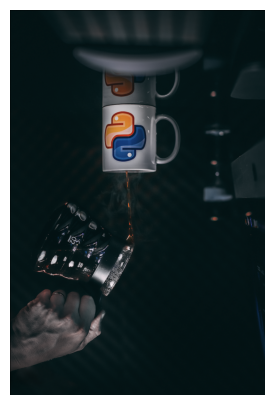

In [23]:
# Perform image rotation
height, width = image.shape[:2]
M = cv2.getRotationMatrix2D((width / 2.0, height / 2.0), 180, 1)
dst_image = cv2.warpAffine(image, M, (width, height))
sig.plot_image(dst_image)

## 1.4 - Image Annotations

The first step to start working with images is to load the necessary libraries. Here, we'll use some familiar ones, including OpenCV.

### 1.4.1 Image Characteristics

To read images, we'll store the image in a variable and load it using `cv2.imread`. This process is similar to how we load datasets from CSV files.


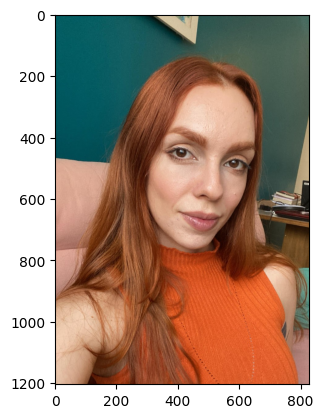

In [24]:
# importando as bibliotecas
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sigmoidal as sig

# ler imagem
image_carmen = Path.cwd().parent.parent / "data" / "carmen.jpg"
img = cv2.imread(image_carmen)

# visualizando a imagem
plt.imshow(img[...,::-1])

We must remember that an image is an array of pixels distributed across channels. That's why we get these three numbers below.

Therefore, we read that our image has 1204 pixels in height, 828 in width, and 3 channels.


In [25]:
print(f'Dimensões da imagem: {img.shape}')

Dimensões da imagem: (1204, 828, 3)


### 1.4.2 - Accessing Specific Pixels

When accessing a specific pixel in an image using OpenCV in Python, the result is a NumPy array representing the color channel values at that pixel. In your example, `img[20, 20]` accesses the pixel at row 20, column 20 of the image.

Meanwhile, `dtype=uint8` indicates that each color channel value is represented by an unsigned 8-bit integer, which is the standard for images in many image processing systems. This means each channel can have a value in the range 0 to 255.


In [26]:
# Acessando o valor do pixel na posição (20, 20)
print(f'{img[20, 20]=}')


img[20, 20]=array([95, 91,  2], dtype=uint8)


### 1.4.3 - Drawing a Rectangle

Just like we do with CSV datasets, it is good practice to create copies before making manipulations. Therefore, we will create a copy of our image before any modifications. Changes made with OpenCV are typically done *inplace*, so having a copy acts as a checkpoint.

The first thing we will do is draw a rectangle. For this, we use the `rectangle` function, which takes as arguments the image to be manipulated, the starting point, the ending point, the rectangle color, and the thickness. This produces the result shown below.


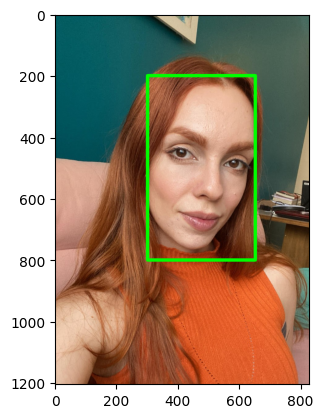

In [27]:

img_cp = img.copy()

# image, start point, end point, rectangle color, thickness
cv2.rectangle(img_cp, (300, 800), (650, 200), (0, 255, 0), 10)

plt.imshow(img_cp[...,::-1]);

### 1.4.4 - Adding Text

Finally, let's write text on top of the image. This can be useful, for example, in a project that identifies people or objects.


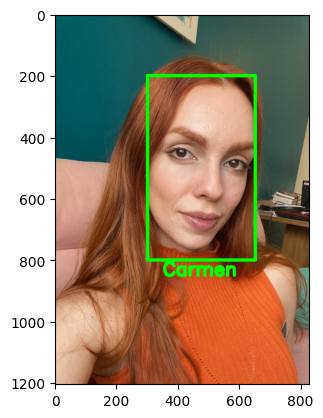

In [28]:
img_cp = img.copy()
cv2.rectangle(img_cp, (300, 800), (650, 200), (0, 255, 0), 10)

font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(img_cp, 'Carmen', (350, 850), font, 2, (0, 255, 0), 10)

plt.imshow(img_cp[...,::-1]);